# 02 — EDA
# Input: data/processed/matches.parquet (from notebook 01)
# Output: figures saved to figures/

First we need to define the date range for the COVID era. The Guardian suggests fans were banned entirely from venues between March 13 2020 and December 2 2020. Spectators were briefly readmitted in limited capacities between December 2020 and January 2021, followed by another strict lockdown until July 19 2021.

For this analysis we will assume the COVID era began on March 13 2020 and ended on July 19 2021. We will treat the brief reintroduction of fans as a part of the COVID era as they were only reintroduced briefly and in lower numbers.

source: https://www.theguardian.com/sport/2021/jul/05/fans-to-be-allowed-back-sporting-venues-no-covid-19-restrictions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
# Load processed data
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "matches.parquet")

# Add home_points, away_points, goal_diff columns
data['home_points'] = data['FTR'].map({'H' : 3, 'D' : 1, 'A' : 0})
data['away_points'] = data['FTR'].map({'H' : 0, 'D' : 1, 'A' : 3})
data['goal_diff'] = data['FTHG'] - data['FTAG']

# Add an era columns (pre_covid, covid, post_covid)
conditions = [
    data['Date'] < pd.Timestamp('2020-03-13'), # pre_covid
    data['Date'] < pd.Timestamp('2021-07-19') #covid
]
choices = ['pre_covid', 'covid']
data['era'] = np.select(conditions, choices, default = 'post_covid')

# Inspect
print(data['era'].value_counts())
print(data.groupby('era')['Date'].agg(['min', 'max']))
print(data[['FTR', 'home_points', 'away_points', 'goal_diff']].head())

era
pre_covid     2188
post_covid    1900
covid          472
Name: count, dtype: int64
                  min        max
era                             
covid      2020-06-17 2021-05-23
post_covid 2021-08-13 2026-05-24
pre_covid  2014-08-16 2020-03-09
  FTR  home_points  away_points  goal_diff
0   H            3            0        1.0
1   D            1            1        0.0
2   A            0            3       -1.0
3   A            0            3       -1.0
4   A            0            3       -1.0


Season
2014-15    0.452632
2015-16    0.413158
2016-17    0.492105
2017-18    0.455263
2018-19    0.476316
2019-20    0.452632
2020-21    0.378947
2021-22    0.428947
2022-23    0.484211
2023-24    0.460526
2024-25    0.407895
2025-26    0.426316
Name: home_win, dtype: float64


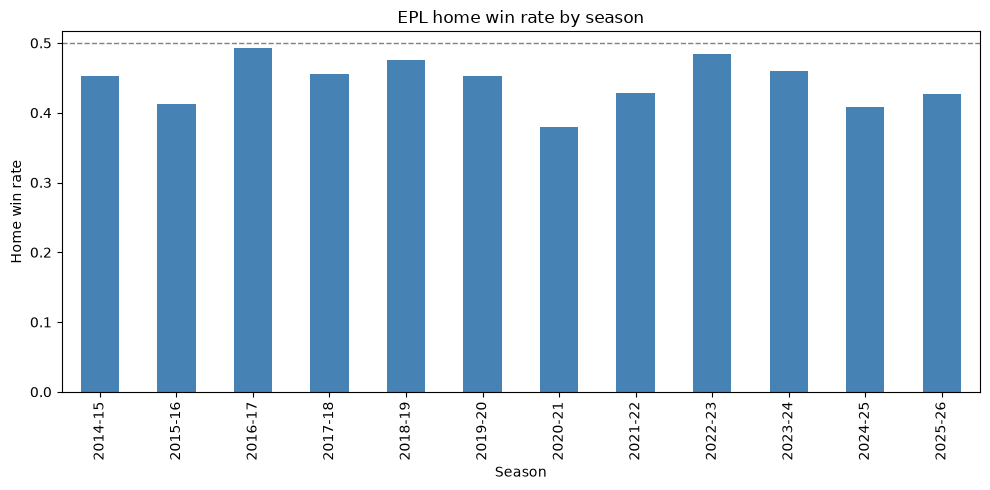

In [3]:
# Compute per season home win rate
data['home_win'] = (data['FTR'] == 'H').astype(int)
home_wr = data.groupby('Season')['home_win'].mean()
print(home_wr)

# Plot home win rate across each season
fig, ax = plt.subplots(figsize=(10,5))
home_wr.plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('Home win rate')
ax.set_xlabel('Season')
ax.set_title('EPL home win rate by season')
plt.tight_layout()

# Save plot 
plt.savefig(PROJECT_ROOT / 'figures' / 'home_win_rate_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

The pre-covid baseline (2014-15 to 2018-19) is roughly 41-49% home win rate which is consistent with historical EPL home advantage of 46% (home teams historically win approximately 46% of all matches). 

The covid era (seasons 2019-20 and 2020-21) is quite interesting, the 2019-20 season has a home win rate of roughly 45% which is consistent with the historical average despite being affected by covid. On the other hand, season 2020-21 shows a significant drop in home win rate (roughy 38%), which is the lowest in the entire 12 year window. 

A possible explanation is that the 2019-20 season was only partly affected by covid (essentially half the season was affected),so the covid portion is small relative to the season. 

The post-covid seasons are mixed (43-48%), roughly back to normal, however not obviously back to pre-covid levels, possibly slightly lower on average. This is worth investigating further.

In [42]:
# Create a new dataframe with team, season, home_ppg, and away_ppg
# This allows us to analyse home vs away ppg for each team across all 12 seasons

home_ppg = (
    data
    .groupby(['Season', 'HomeTeam'])['home_points']
    .mean()
    .reset_index()
    .rename(columns={'HomeTeam': 'team', 'home_points': 'home_ppg'})
)

away_ppg = (
    data
    .groupby(['Season', 'AwayTeam'])['away_points']
    .mean()
    .reset_index()
    .rename(columns={'AwayTeam': 'team', 'away_points': 'away_ppg'})
)

# Merge the two intermediate dataframes
team_ppg = pd.merge(home_ppg, away_ppg, on=['Season', 'team'])

# Add the delta column
team_ppg['ppg_diff'] = team_ppg['home_ppg'] - team_ppg['away_ppg']

# Inspect
print(team_ppg['ppg_diff'].describe())
print(team_ppg['ppg_diff'].mean())

count    240.000000
mean       0.376974
std        0.391537
min       -0.789474
25%        0.157895
50%        0.368421
75%        0.631579
max        1.631579
Name: ppg_diff, dtype: float64
0.37697368421052635


In [43]:
# Perform a paired t-test
from scipy.stats import ttest_rel
result = ttest_rel(team_ppg['home_ppg'], team_ppg['away_ppg'])
ci = result.confidence_interval()
print(result)
print(f"Mean diff: {team_ppg['ppg_diff'].mean():.3f}")
print(f"95% CI: [{ci.low:.3f}, {ci.high:.3f}]")

TtestResult(statistic=np.float64(14.915714786519233), pvalue=np.float64(5.263158210060423e-36), df=np.int64(239))
Mean diff: 0.377
95% CI: [0.327, 0.427]


The paired t-test output was:
- t-value = 14.915714786519233
- p-value = 5.263158210060423e-36

Additionally, the mean difference in home_ppg vs away_ppg of 0.377 lies within the 95% confidence interval (0.327, 0.427).
